## Re-ID 성능 진단 노트북

현재 Re-ID 파이프라인의 **같은 사람을 다른 사람으로 인식하는 문제**를 정량적으로 진단하고,
개선 방향(임계값 조정, 모델 교체, Matcher 전략 변경)의 효과를 미리 검증합니다.

### 진단 항목
1. **임베딩 유사도 분포** — 같은 사람(intra-track) vs 다른 사람(inter-track) 코사인 유사도
2. **임계값 스윕** — 0.50 ~ 0.90 구간에서 FN율(재인식 실패) / FP율(오인식) 추적
3. **모델 비교** — `osnet_x0_25` vs `osnet_x1_0` 임베딩 품질
4. **Matcher 전략 비교** — 현재(단일 detection 비교) vs 개선안(global_id별 평균 벡터 비교)

### 목차

| # | 섹션 | 내용 |
|---|------|------|
| 0 | [환경 설정](#0.-환경-설정) | PyTorch, CUDA, 라이브러리 임포트 |
| 1 | [실험 설정](#1.-실험-설정) | 비디오 경로, 모델 목록, 임계값 범위 파라미터 |15300003.avi
| 2 | [임베딩 수집 함수](#2.-임베딩-수집-함수) | YOLO → BoxMOT → OSNet 파이프라인 수집 함수 정의 |
| 3 | [임베딩 수집 실행](#3.-임베딩-수집-실행) | 테스트 비디오에서 track별 임베딩 수집 |
| 4 | [유사도 분포 분석](#4.-유사도-분포-분석-—-핵심-진단) | intra/inter-track 코사인 유사도 분포 + 최적 임계값 탐색 |
| 5 | [모델 비교](#5.-모델-비교-—-osnet_x0_25-vs-osnet_x1_0) | osnet_x0_25 vs osnet_x1_0 분리도(d') 비교 |
| 6 | [Matcher 전략 비교](#6.-Matcher-전략-비교) | 단일 detection 비교 vs global_id 평균 벡터 비교 |
| 7 | [매칭 실패 사례 시각화](#7.-매칭-실패-사례-시각화) | 같은 사람인데 매칭 실패한 썸네일 쌍 시각화 |
| 8 | [최종 요약 및 권고사항](#8.-최종-요약-및-권고사항) | 권장 임계값·모델·Matcher 전략 자동 출력 |
| 9 | [개선 전후 비교](#9.-개선-전후-비교) | 임계값 변경 전후 FN율·FP율·Rank-1 시각적 비교 |
| 10 | [추적기 품질 진단](#10.-추적기-품질-진단) | BoxMOT ID switch 감지: 썸네일 그리드 + 임베딩 연속성 분석 |


### 용어 설명

노트북 전반에 걸쳐 등장하는 핵심 용어들을 정리합니다.

| 용어 | 설명 |
|------|------|
| **Re-ID (재식별, Re-Identification)** | 서로 다른 카메라 또는 시간대에서 같은 사람을 동일 인물로 인식하는 기술. 외모 임베딩 벡터의 유사도로 판단합니다. |
| **임베딩 벡터 (Embedding Vector)** | OSNet 신경망이 인물 이미지에서 추출한 512차원 특징 벡터. 같은 사람은 유사한 벡터를, 다른 사람은 상이한 벡터를 가집니다. |
| **코사인 유사도 (Cosine Similarity)** | 두 벡터 간의 방향 유사도. L2 정규화된 벡터끼리의 내적과 동일하며, 1에 가까울수록 동일 인물일 가능성이 높습니다. |
| **intra-track 유사도** | 동일 Track ID 내 서로 다른 프레임에서 추출한 임베딩 쌍의 코사인 유사도. 이상적으로는 높아야 합니다. |
| **inter-track 유사도** | 서로 다른 Track ID(다른 사람) 간 임베딩의 코사인 유사도. 이상적으로는 낮아야 합니다. |
| **FN율 (False Negative Rate)** | 같은 사람인데 임계값 미달로 "새 사람"으로 잘못 분류한 비율 (재인식 실패). FN율이 높을수록 같은 사람이 여러 개의 ID로 쪼개집니다. |
| **FP율 (False Positive Rate)** | 다른 사람인데 임계값 이상으로 "같은 사람"으로 잘못 분류한 비율 (오인식). FP율이 높을수록 다른 사람이 하나의 ID로 합쳐집니다. |
| **분리도 d'** | `(intra 평균 - inter 평균) / 전체 표준편차`. 같은 사람과 다른 사람의 임베딩 분포가 얼마나 잘 분리되는지 나타내는 지표. 클수록 좋습니다. |
| **Rank-1 정확도** | query 임베딩에 대해 gallery 중 가장 유사한 1건을 찾았을 때 실제로 같은 사람일 확률. Re-ID 성능의 대표 지표입니다. |
| **임계값 (REID_SIMILARITY_THRESHOLD)** | 코사인 유사도가 이 값 이상이면 "같은 사람"으로 매칭, 미만이면 새 사람으로 등록. `.env`에서 설정하며 기본값은 0.85입니다. |
| **Track ID** | BoxMOT(BotSort)가 단일 카메라 영상 내에서 부여하는 임시 추적 ID. 카메라가 바뀌거나 화면에서 사라지면 새로운 ID가 부여됩니다. |
| **Global ID** | 서버(PostgreSQL)에서 관리하는 전역 인물 ID. Re-ID 매칭으로 같은 사람임이 확인되면 여러 Track ID가 하나의 Global ID로 연결됩니다. |
| **L2 정규화** | 벡터를 크기(norm)로 나눠 단위 구 위에 올려놓는 연산. 이후 내적 연산이 코사인 유사도와 동일해집니다. |
| **gallery / query 분리** | Re-ID 평가 프로토콜. 각 트랙 임베딩의 앞 절반을 gallery(등록), 뒤 절반을 query(검색)로 사용해 실제 운영 환경을 시뮬레이션합니다. |


### 0. 환경 설정

In [1]:
import os
import sys

# edge/ 디렉토리를 파이썬 경로에 추가 (노트북 위치 또는 프로젝트 루트 기준 자동 감지)
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == 'notebooks':
    edge_root = os.path.abspath(os.path.join(current_dir, '..'))
elif 'edge' in os.listdir(current_dir):
    edge_root = os.path.abspath(os.path.join(current_dir, 'edge'))
else:
    edge_root = current_dir

if edge_root not in sys.path:
    sys.path.insert(0, edge_root)
print(f'edge root: {edge_root}')

import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False
import matplotlib.patches as mpatches
from collections import defaultdict
import torch
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'사용 디바이스: {DEVICE}')

edge root: c:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID) 시스템\EYE-D\edge
PyTorch: 2.12.0+cpu
CUDA available: False
사용 디바이스: cpu


### 1. 실험 설정

In [2]:
# ── 실험 파라미터 (필요 시 수정) ──────────────────────────────────────────────
# edge_root 경로를 기반으로 비디오 파일 경로 자동 지정
VIDEO_PATH = os.path.abspath(os.path.join(edge_root, '..', 'data', 'converted', '16300000.avi'))
MAX_FRAMES    = 400                 # 분석할 최대 프레임 수 (많을수록 정확, 느림)
# MAX_FRAMES    = float('inf')          # 분석할 최대 프레임 수 (많을수록 정확, 느림)
MIN_BBOX_SIZE = 40                    # 유효 bounding box 최소 크기 (px)
CONF_THRESH   = 0.40                  # YOLO confidence 임계값

# 비교할 모델 목록
MODELS_TO_TEST = ['osnet_x0_25']

# 임계값 스윕 구간
THRESHOLD_RANGE = np.arange(0.45, 0.95, 0.01)

# 현재 운영 임계값
CURRENT_THRESHOLD = 0.85
# ─────────────────────────────────────────────────────────────────────────────

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f'비디오 파일을 찾을 수 없습니다: {VIDEO_PATH}\n'
        '  VIDEO_PATH 를 올바른 경로로 수정하거나 '
        'run_batch.sh 에 유효한 파일 경로를 전달하세요.'
    )
else:
    cap = cv2.VideoCapture(VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    print(f'비디오: {total_frames}프레임  |  {fps:.1f} FPS  |  분석 범위: {min(MAX_FRAMES, total_frames)}프레임')
OUTPUT_DIR = 'results'          # 결과 저장 폴더 (papermill -p OUTPUT_DIR ... 으로 덮어쓰기)


비디오: 43200프레임  |  24.0 FPS  |  분석 범위: 400프레임


### 2. 임베딩 수집 함수

In [3]:
from ultralytics import YOLO
from boxmot.trackers.tracker_zoo import create_tracker
from src.core.reid_extractor import ReIDExtractor
from src.core.tracker import TrackResult


def collect_embeddings(video_path, model_name='osnet_x0_25', max_frames=300, verbose=True):
    """
    비디오를 프레임 단위로 읽어 track별 임베딩을 수집합니다.
    
    Returns
    -------
    dict[int, list[dict]]
        {track_id: [{'frame': int, 'vector': np.ndarray(512,), 'bbox': list, 'thumbnail': ndarray}]}
    """
    half = (DEVICE != 'cpu')
    weights = f'{model_name}_msmt17.pt'

    if verbose:
        print(f'[{model_name}] 모델 로드 중...')

    detector = YOLO('yolov8n.pt')
    tracker  = create_tracker('botsort', reid_weights=weights, device=DEVICE, half=half)
    reid     = ReIDExtractor(model_name=model_name, use_onnx=False)
    
    cap = cv2.VideoCapture(video_path)
    track_data = defaultdict(list)
    frame_idx  = 0

    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        # ── 탐지 ────────────────────────────────────────────────────────────
        det_results = detector.predict(frame, conf=CONF_THRESH, classes=[0], verbose=False)
        if len(det_results[0].boxes) == 0:
            tracker.update(np.empty((0, 6)), frame)
            continue

        dets   = det_results[0].boxes.data.cpu().numpy()
        tracks = tracker.update(dets, frame)
        if len(tracks) == 0:
            continue

        # ── 추적 결과 래핑 ───────────────────────────────────────────────────
        track_results = [
            TrackResult(
                track_id=int(t[4]),
                bbox=[int(t[0]), int(t[1]), int(t[2]), int(t[3])],
                confidence=float(t[5])
            )
            for t in tracks if t[5] >= CONF_THRESH
        ]

        # ── Re-ID 추출 ──────────────────────────────────────────────────────
        reid_vecs = reid.extract(frame, track_results)

        for rv in reid_vecs:
            bbox = rv['bbox']
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
            if w < MIN_BBOX_SIZE or h < MIN_BBOX_SIZE:
                continue

            # L2 정규화 (코사인 유사도 계산을 위해)
            vec  = np.array(rv['vector'], dtype=np.float32)
            norm = np.linalg.norm(vec)
            vec  = vec / (norm + 1e-8)

            roi   = frame[bbox[1]:bbox[3], bbox[0]:bbox[2]]
            thumb = cv2.resize(roi, (64, 128)) if roi.size > 0 else None

            track_data[rv['track_id']].append({
                'frame':     frame_idx,
                'vector':    vec,
                'bbox':      bbox,
                'thumbnail': thumb,
            })

    cap.release()

    n_tracks = len(track_data)
    n_embeds = sum(len(v) for v in track_data.values())
    if verbose:
        print(f'  수집 완료 → 트랙 {n_tracks}개  |  총 임베딩 {n_embeds}개')
    return dict(track_data)


print('collect_embeddings 함수 정의 완료')

collect_embeddings 함수 정의 완료


### 3. 임베딩 수집 실행

In [4]:
# 먼저 현재 운영 모델(osnet_x0_25)로 수집
data_x025 = collect_embeddings(VIDEO_PATH, model_name='osnet_x0_25', max_frames=MAX_FRAMES)

# 트랙별 프레임 수 요약
counts = sorted([(tid, len(recs)) for tid, recs in data_x025.items()], key=lambda x: -x[1])
print(f'\n트랙별 임베딩 수 (상위 10개): {counts[:10]}')

[osnet_x0_25] 모델 로드 중...


INFO     BoxMOT v18.0.0 🚀 Python-3.11.7 torch-2.12.0+cpuCPU

INFO     C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)  
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x0_25_msmt17.pt

INFO     [PID 12632] Downloading ReID weights from https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF
         → C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x0_25_msmt17.pt

INFO     Downloading osnet_x0_25_msmt17.pt...

...

INFO     BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=None,           
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at                  
         0x000001DF502453D0>, track_high_thresh=0.6, track_low_thresh=0.1, new_track_thresh=0.7, track_buffer=30,  
         match_thresh=0.8, proximity_thresh=0.5, appearance_thresh=0.25, cmc_method=ecc, frame_rate=30,            
         fuse_first_associate=False, with_reid=True

INFO     C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)  
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x0_25_msmt17.pt

INFO     [PID 12632] Found existing ReID weights at C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이   
         기반 지능형 침입 탐지 및 인물 재식별(Re-ID)                                                               
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x0_25_msmt17.pt; skipping download.

INFO     Loaded pretrained weights from C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형   
         침입 탐지 및 인물 재식별(Re-ID) 시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x0_25_msmt17.pt

  수집 완료 → 트랙 2개  |  총 임베딩 800개

트랙별 임베딩 수 (상위 10개): [(1, 400), (2, 400)]


In [5]:
# 데이터 수집 결과 검증
valid_tracks = {k: v for k, v in data_x025.items() if len(v) >= 3}
HAS_DATA = len(valid_tracks) >= 2  # 유사도 비교에는 최소 2개 트랙 필요

if not HAS_DATA:
    print('[경고] 유효 트랙이 부족합니다 (필요: 2개 이상, 수집됨: '
          f'{len(valid_tracks)}개)')
    print('  가능한 원인 및 조치:')
    print(f'    CONF_THRESH={CONF_THRESH}  → 0.25 로 낮춰 보세요')
    print(f'    MIN_BBOX_SIZE={MIN_BBOX_SIZE}  → 20 으로 낮춰 보세요')
    print(f'    MAX_FRAMES={MAX_FRAMES} 내에 사람이 등장하는지 확인하세요')
    print('  이후 분석 셀은 데이터 없이 건너뜁니다.')
else:
    print(f'유효 트랙 {len(valid_tracks)}개 — 분석을 계속합니다.')


유효 트랙 2개 — 분석을 계속합니다.


### 4. 유사도 분포 분석 — 핵심 진단

In [6]:
def compute_similarity_distributions(track_data, max_per_track=15):
    """
    intra-track(같은 사람, 다른 프레임)과 inter-track(다른 사람) 코사인 유사도 분포를 계산합니다.
    이미 L2 정규화된 벡터를 가정하므로 내적 = 코사인 유사도입니다.
    """
    # 임베딩이 3개 이상인 트랙만 사용 (신뢰성 확보)
    valid = {k: v for k, v in track_data.items() if len(v) >= 3}
    track_ids = list(valid.keys())

    intra_sims = []
    inter_sims = []

    # ── intra-track ─────────────────────────────────────────────────────────
    for tid, recs in valid.items():
        vecs = np.stack([r['vector'] for r in recs[:max_per_track]])
        n = len(vecs)
        for i in range(n):
            for j in range(i + 1, n):
                intra_sims.append(float(np.dot(vecs[i], vecs[j])))

    # ── inter-track : 트랙별 평균 벡터로 비교 ────────────────────────────────
    mean_vecs = {}
    for tid, recs in valid.items():
        vecs = np.stack([r['vector'] for r in recs[:max_per_track]])
        mv   = vecs.mean(axis=0)
        mean_vecs[tid] = mv / (np.linalg.norm(mv) + 1e-8)

    for i, tid1 in enumerate(track_ids):
        for tid2 in track_ids[i + 1:]:
            inter_sims.append(float(np.dot(mean_vecs[tid1], mean_vecs[tid2])))

    return np.array(intra_sims), np.array(inter_sims)


intra_x025, inter_x025 = compute_similarity_distributions(data_x025)
print(f'intra-track 유사도: {len(intra_x025)}쌍  |  mean={intra_x025.mean():.3f}  std={intra_x025.std():.3f}')
print(f'inter-track 유사도: {len(inter_x025)}쌍  |  mean={inter_x025.mean():.3f}  std={inter_x025.std():.3f}')

intra-track 유사도: 210쌍  |  mean=0.975  std=0.014
inter-track 유사도: 1쌍  |  mean=0.471  std=0.000


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

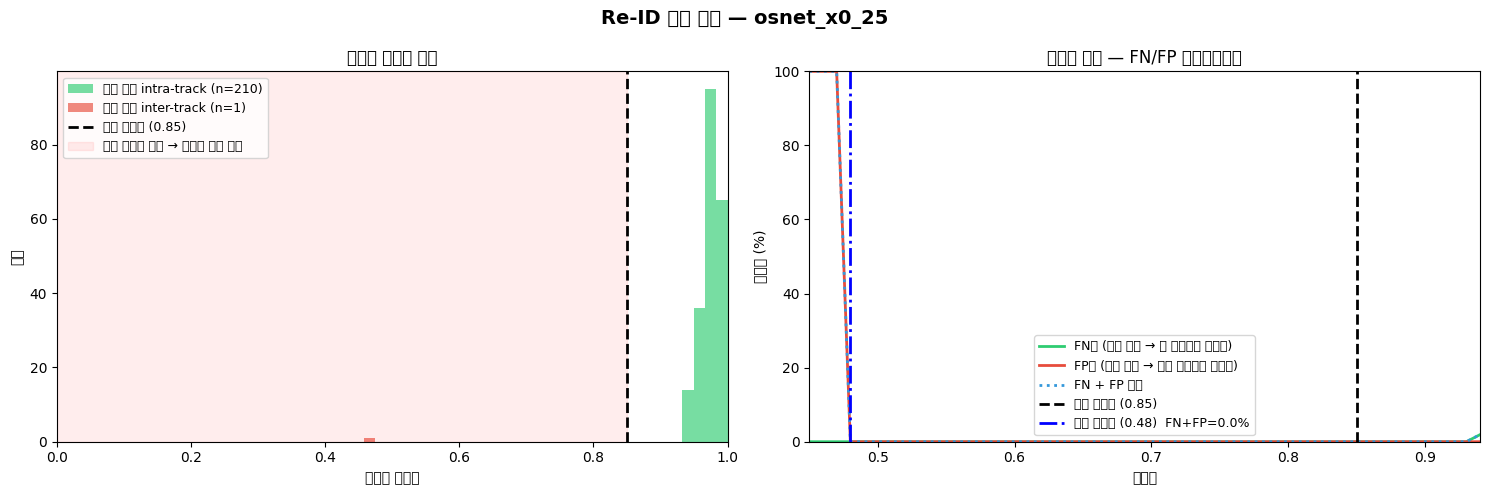


[osnet_x0_25] 현재 임계값 0.85:
  FN율 = 0.0%  (같은 사람을 새 사람으로 인식)
  FP율 = 0.0%  (다른 사람을 같은 사람으로 인식)

  권장 임계값: 0.48  (FN+FP 최소, 오류율 0.0%)


In [7]:
def plot_similarity_analysis(intra, inter, model_name, current_thresh=CURRENT_THRESHOLD):
    """유사도 분포 + 임계값 스윕 차트를 그립니다."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Re-ID 성능 진단 — {model_name}', fontsize=14, fontweight='bold')

    # ── 왼쪽: 유사도 분포 히스토그램 ────────────────────────────────────────
    ax = axes[0]
    bins = np.linspace(0, 1, 60)
    ax.hist(intra, bins=bins, alpha=0.65, color='#2ecc71', label=f'같은 사람 intra-track (n={len(intra)})')
    ax.hist(inter, bins=bins, alpha=0.65, color='#e74c3c', label=f'다른 사람 inter-track (n={len(inter)})')
    ax.axvline(current_thresh, color='black', lw=2, ls='--', label=f'현재 임계값 ({current_thresh})')

    # 현재 임계값에서 FN 영역 음영
    ax.axvspan(0, current_thresh, alpha=0.07, color='red', label='현재 임계값 미만 → 재인식 실패 영역')

    ax.set_xlabel('코사인 유사도')
    ax.set_ylabel('빈도')
    ax.set_title('임베딩 유사도 분포')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

    # ── 오른쪽: 임계값별 FN율/FP율 ──────────────────────────────────────────
    ax = axes[1]
    thresholds = THRESHOLD_RANGE
    fn_rates, fp_rates = [], []

    for t in thresholds:
        fn = (intra < t).mean() if len(intra) > 0 else 0  # 같은 사람을 놓침
        fp = (inter >= t).mean() if len(inter) > 0 else 0  # 다른 사람을 같다고 함
        fn_rates.append(fn)
        fp_rates.append(fp)

    fn_rates = np.array(fn_rates)
    fp_rates = np.array(fp_rates)
    total    = fn_rates + fp_rates
    opt_idx  = np.argmin(total)
    opt_t    = thresholds[opt_idx]

    ax.plot(thresholds, fn_rates * 100, '#2ecc71', lw=2, label='FN율 (같은 사람 → 새 사람으로 오분류)')
    ax.plot(thresholds, fp_rates * 100, '#e74c3c', lw=2, label='FP율 (다른 사람 → 같은 사람으로 오분류)')
    ax.plot(thresholds, total   * 100, '#3498db', lw=2, ls=':', label='FN + FP 합계')
    ax.axvline(current_thresh, color='black', lw=2, ls='--', label=f'현재 임계값 ({current_thresh})')
    ax.axvline(opt_t,          color='blue',  lw=2, ls='-.',
               label=f'최적 임계값 ({opt_t:.2f})  FN+FP={total[opt_idx]*100:.1f}%')

    ax.set_xlabel('임계값')
    ax.set_ylabel('오류율 (%)')
    ax.set_title('임계값 스윕 — FN/FP 트레이드오프')
    ax.legend(fontsize=9)
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

    # 현재 임계값 진단 출력
    curr_idx = np.searchsorted(thresholds, current_thresh)
    curr_idx = min(curr_idx, len(thresholds) - 1)
    print(f'\n[{model_name}] 현재 임계값 {current_thresh:.2f}:')
    print(f'  FN율 = {fn_rates[curr_idx]*100:.1f}%  (같은 사람을 새 사람으로 인식)')
    print(f'  FP율 = {fp_rates[curr_idx]*100:.1f}%  (다른 사람을 같은 사람으로 인식)')
    print(f'\n  권장 임계값: {opt_t:.2f}  (FN+FP 최소, 오류율 {total[opt_idx]*100:.1f}%)')
    return opt_t


opt_threshold_x025 = plot_similarity_analysis(intra_x025, inter_x025, 'osnet_x0_25')

### 5. 모델 비교 — `osnet_x0_25` vs `osnet_x1_0`

In [8]:
# osnet_x1_0으로 임베딩 수집 (시간이 걸릴 수 있습니다)
data_x1 = collect_embeddings(VIDEO_PATH, model_name='osnet_x1_0', max_frames=MAX_FRAMES)
intra_x1, inter_x1 = compute_similarity_distributions(data_x1)

[osnet_x1_0] 모델 로드 중...


INFO     BoxMOT v18.0.0 🚀 Python-3.11.7 torch-2.12.0+cpuCPU

INFO     C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)  
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x1_0_msmt17.pt

INFO     [PID 12632] Downloading ReID weights from https://drive.google.com/uc?id=112EMUfBPYeYg70w-syK6V6Mx8-Qb9Q1M
         → C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x1_0_msmt17.pt

INFO     Downloading osnet_x1_0_msmt17.pt...

...

INFO     BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=None,           
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at                  
         0x000001DF54E66450>, track_high_thresh=0.6, track_low_thresh=0.1, new_track_thresh=0.7, track_buffer=30,  
         match_thresh=0.8, proximity_thresh=0.5, appearance_thresh=0.25, cmc_method=ecc, frame_rate=30,            
         fuse_first_associate=False, with_reid=True

INFO     C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형 침입 탐지 및 인물 재식별(Re-ID)  
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x1_0_msmt17.pt

INFO     [PID 12632] Found existing ReID weights at C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이   
         기반 지능형 침입 탐지 및 인물 재식별(Re-ID)                                                               
         시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x1_0_msmt17.pt; skipping download.

INFO     Loaded pretrained weights from C:\Users\murim\OneDrive\문서\Claude\Projects\엣지 게이트웨이 기반 지능형   
         침입 탐지 및 인물 재식별(Re-ID) 시스템\EYE-D\.venv\Lib\site-packages\models\osnet_x1_0_msmt17.pt

  수집 완료 → 트랙 2개  |  총 임베딩 800개


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

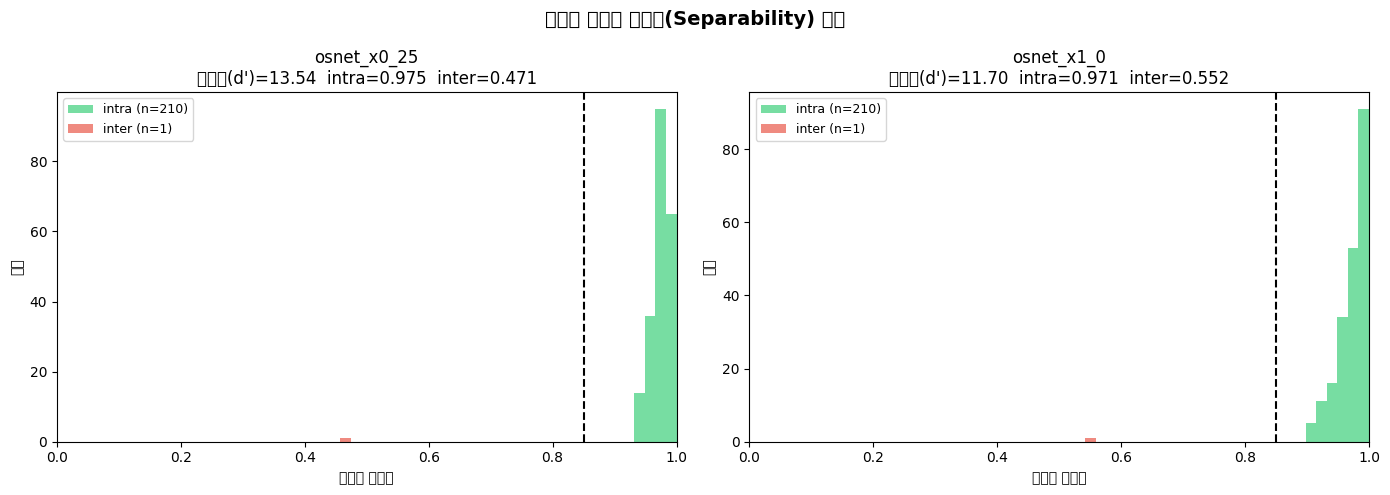


[모델 분리도 비교]
  모델                       intra평균     inter평균     분리도(d')
  -------------------------------------------------------
  osnet_x0_25                0.975       0.471       13.54
  osnet_x1_0                 0.971       0.552       11.70


In [9]:
def plot_model_comparison(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle('모델별 임베딩 분리도(Separability) 비교', fontsize=14, fontweight='bold')

    summary = []
    for ax, (mname, intra, inter) in zip(axes, results):
        bins = np.linspace(0, 1, 60)
        ax.hist(intra, bins=bins, alpha=0.65, color='#2ecc71', label=f'intra (n={len(intra)})')
        ax.hist(inter, bins=bins, alpha=0.65, color='#e74c3c', label=f'inter (n={len(inter)})')
        ax.axvline(CURRENT_THRESHOLD, color='black', lw=1.5, ls='--')

        all_sims = np.concatenate([intra, inter])
        sep = (intra.mean() - inter.mean()) / (all_sims.std() + 1e-8)
        summary.append((mname, intra.mean(), inter.mean(), sep))

        ax.set_title(f"{mname}\n분리도(d')={sep:.2f}  intra={intra.mean():.3f}  inter={inter.mean():.3f}")
        ax.set_xlabel('코사인 유사도')
        ax.set_ylabel('빈도')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    sep_col = "분리도(d')"
    print('\n[모델 분리도 비교]')
    print(f"  {'모델':<20}  {'intra평균':>10}  {'inter평균':>10}  {sep_col:>10}")
    print('  ' + '-' * 55)
    for mname, im, nm, sep in sorted(summary, key=lambda x: -x[3]):
        print(f'  {mname:<20}  {im:>10.3f}  {nm:>10.3f}  {sep:>10.2f}')


plot_model_comparison([
    ('osnet_x0_25', intra_x025, inter_x025),
    ('osnet_x1_0',  intra_x1,   inter_x1),
])


### 6. Matcher 전략 비교

현재 `matcher.py`는 `detections` 테이블의 개별 레코드 1건과 비교합니다.  
아래에서는 **global_id별 평균 벡터**와 비교하는 방식의 효과를 시뮬레이션합니다.

In [10]:
def simulate_matcher(track_data, threshold, strategy='single'):
    """
    Re-ID 매칭을 시뮬레이션합니다.
    
    strategy:
      'single' — 현재 방식: 등록된 임베딩 중 가장 가까운 1건과 비교
      'mean'   — 개선안: global_id별 평균 벡터와 비교
    
    시뮬레이션 방법:
      각 트랙의 임베딩을 절반씩 gallery/query로 분리.
      query 임베딩이 올바른 gallery(같은 track_id)에 매칭되는 비율 = Rank-1 정확도.
    
    Returns
    -------
    dict with keys: rank1_accuracy, match_rate, new_id_rate
    """
    valid = {k: v for k, v in track_data.items() if len(v) >= 4}
    if len(valid) < 2:
        return {'rank1_accuracy': 0, 'match_rate': 0, 'new_id_rate': 1}

    # gallery: 각 트랙의 앞 절반, query: 뒤 절반
    gallery = {}  # {track_id: [vec, ...]}
    queries  = []  # [(track_id, vec)]

    for tid, recs in valid.items():
        mid   = max(2, len(recs) // 2)
        gallery[tid] = [r['vector'] for r in recs[:mid]]
        for r in recs[mid:]:
            queries.append((tid, r['vector']))

    correct = 0
    matched = 0
    total   = len(queries)

    for true_tid, q_vec in queries:
        best_sim  = -1.0
        best_tid  = None

        for g_tid, g_vecs in gallery.items():
            if strategy == 'mean':
                g_mean = np.mean(g_vecs, axis=0)
                g_mean = g_mean / (np.linalg.norm(g_mean) + 1e-8)
                sim = float(np.dot(q_vec, g_mean))
            else:  # single: 가장 가까운 1개
                sims = [float(np.dot(q_vec, gv)) for gv in g_vecs]
                sim  = max(sims)

            if sim > best_sim:
                best_sim = sim
                best_tid = g_tid

        if best_sim >= threshold:
            matched += 1
            if best_tid == true_tid:
                correct += 1

    rank1    = correct / total if total > 0 else 0
    match_r  = matched / total if total > 0 else 0
    new_id_r = 1 - match_r

    return {
        'rank1_accuracy': rank1,
        'match_rate':     match_r,
        'new_id_rate':    new_id_r,
        'total_queries':  total,
    }


print('simulate_matcher 정의 완료')

simulate_matcher 정의 완료


In [11]:
# 임계값 스윕: single vs mean 전략 비교
sweep_thresholds = np.arange(0.50, 0.90, 0.05)
rows = []

for t in sweep_thresholds:
    r_single = simulate_matcher(data_x025, threshold=t, strategy='single')
    r_mean   = simulate_matcher(data_x025, threshold=t, strategy='mean')
    rows.append({
        'threshold': t,
        'single_rank1':    r_single['rank1_accuracy'],
        'single_match':    r_single['match_rate'],
        'mean_rank1':      r_mean['rank1_accuracy'],
        'mean_match':      r_mean['match_rate'],
    })

# 출력
print(f'{"임계값":>8}  {"[single] Rank-1":>16}  {"Match율":>8}  {"[mean] Rank-1":>15}  {"Match율":>8}')
print('-' * 65)
for r in rows:
    curr = ' ← 현재' if abs(r['threshold'] - CURRENT_THRESHOLD) < 0.01 else ''
    print(f"{r['threshold']:>8.2f}  "
          f"{r['single_rank1']:>15.1%}  {r['single_match']:>8.1%}  "
          f"{r['mean_rank1']:>14.1%}  {r['mean_match']:>8.1%}{curr}")

     임계값   [single] Rank-1    Match율    [mean] Rank-1    Match율
-----------------------------------------------------------------
    0.50           100.0%    100.0%          100.0%    100.0%
    0.55           100.0%    100.0%          100.0%    100.0%
    0.60           100.0%    100.0%          100.0%    100.0%
    0.65           100.0%    100.0%          100.0%    100.0%
    0.70           100.0%    100.0%          100.0%    100.0%
    0.75           100.0%    100.0%          100.0%    100.0%
    0.80            90.2%     90.2%           89.2%     89.2%
    0.85            70.5%     70.5%           60.0%     60.0% ← 현재


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

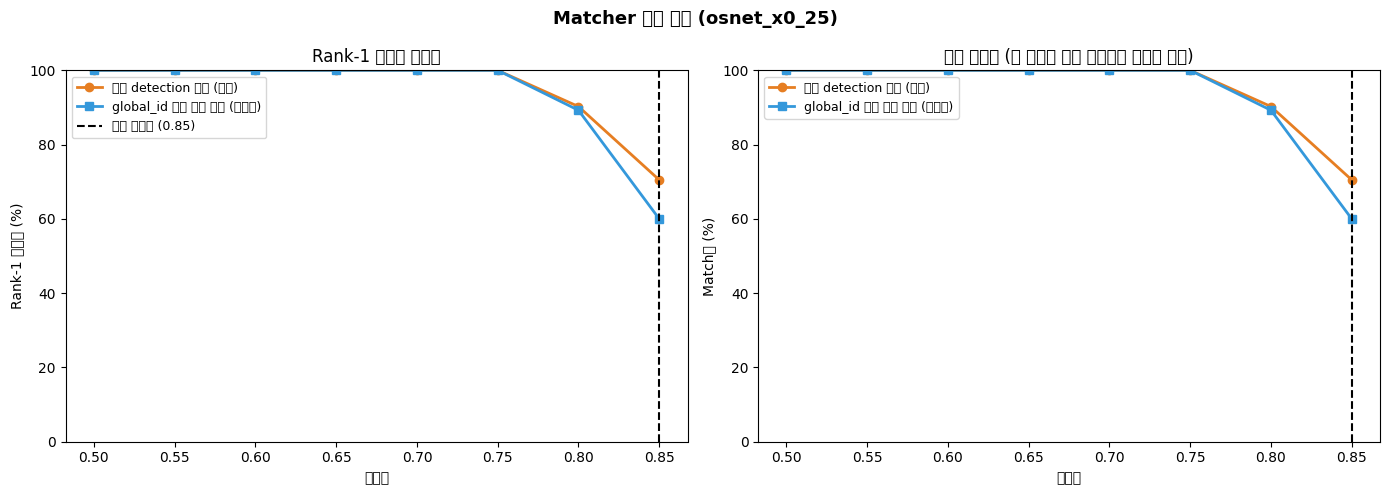

In [12]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matcher 전략 비교 (osnet_x0_25)', fontsize=13, fontweight='bold')

ts = [r['threshold']    for r in rows]
s1 = [r['single_rank1'] for r in rows]
m1 = [r['mean_rank1']   for r in rows]
sm = [r['single_match'] for r in rows]
mm = [r['mean_match']   for r in rows]

ax = axes[0]
ax.plot(ts, [v * 100 for v in s1], 'o-', color='#e67e22', lw=2, label='단일 detection 비교 (현재)')
ax.plot(ts, [v * 100 for v in m1], 's-', color='#3498db', lw=2, label='global_id 평균 벡터 비교 (개선안)')
ax.axvline(CURRENT_THRESHOLD, color='black', lw=1.5, ls='--', label=f'현재 임계값 ({CURRENT_THRESHOLD})')
ax.set_xlabel('임계값')
ax.set_ylabel('Rank-1 정확도 (%)')
ax.set_title('Rank-1 재인식 정확도')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)

ax = axes[1]
ax.plot(ts, [v * 100 for v in sm], 'o-', color='#e67e22', lw=2, label='단일 detection 비교 (현재)')
ax.plot(ts, [v * 100 for v in mm], 's-', color='#3498db', lw=2, label='global_id 평균 벡터 비교 (개선안)')
ax.axvline(CURRENT_THRESHOLD, color='black', lw=1.5, ls='--')
ax.set_xlabel('임계값')
ax.set_ylabel('Match율 (%)')
ax.set_title('매칭 성공률 (새 사람을 기존 사람으로 연결한 비율)')
ax.legend(fontsize=9)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### 7. 매칭 실패 사례 시각화

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

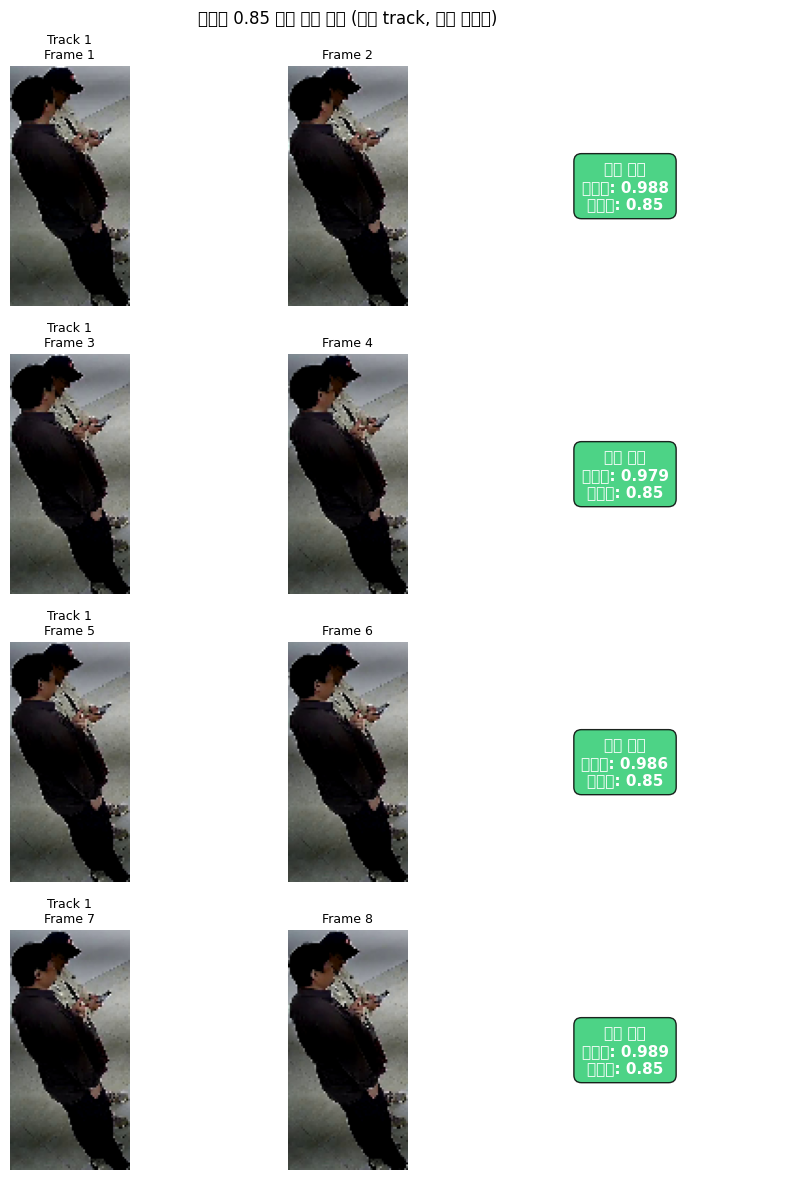


현재 임계값 0.85에서:
  매칭 실패 사례: 0건  |  매칭 성공 사례: 400건


In [13]:
def show_matching_examples(track_data, threshold=CURRENT_THRESHOLD, n_examples=4):
    """같은 트랙 내 임베딩 쌍 중 현재 임계값에서 매칭 실패한 사례를 보여줍니다."""
    valid = {k: v for k, v in track_data.items() if len(v) >= 3}

    failed_pairs  = []  # (sim, tid, rec_a, rec_b)
    success_pairs = []

    for tid, recs in valid.items():
        for i in range(0, len(recs) - 1, 2):  # 격프레임으로 샘플링
            a, b = recs[i], recs[i + 1]
            if a['thumbnail'] is None or b['thumbnail'] is None:
                continue
            sim = float(np.dot(a['vector'], b['vector']))
            pair = (sim, tid, a, b)
            if sim < threshold:
                failed_pairs.append(pair)
            else:
                success_pairs.append(pair)

    # 유사도 낮은 순 정렬 (가장 심한 실패 사례 먼저)
    failed_pairs.sort(key=lambda x: x[0])

    n_fail    = min(n_examples, len(failed_pairs))
    n_success = min(n_examples, len(success_pairs))
    n_total   = n_fail + n_success

    if n_total == 0:
        print('표시할 예시가 없습니다.')
        return

    fig, axes = plt.subplots(n_total, 3, figsize=(9, 3 * n_total))
    if n_total == 1:
        axes = [axes]
    
    fig.suptitle(f'임계값 {threshold:.2f} 기준 매칭 결과 (같은 track, 다른 프레임)', fontsize=12)

    def draw_row(ax_row, sim, tid, rec_a, rec_b, success):
        color = '#2ecc71' if success else '#e74c3c'
        label = '매칭 성공' if success else '매칭 실패'

        for ax, rec, title in zip(ax_row[:2], [rec_a, rec_b], [f'Track {tid}\nFrame {rec_a["frame"]}', f'Frame {rec_b["frame"]}']):
            ax.imshow(cv2.cvtColor(rec['thumbnail'], cv2.COLOR_BGR2RGB))
            ax.set_title(title, fontsize=9)
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

        ax_row[2].text(0.5, 0.5, f'{label}\n유사도: {sim:.3f}\n임계값: {threshold:.2f}',
                       ha='center', va='center', fontsize=11,
                       color='white', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.85))
        ax_row[2].axis('off')

    row = 0
    for sim, tid, ra, rb in failed_pairs[:n_fail]:
        draw_row(axes[row], sim, tid, ra, rb, success=False)
        row += 1
    for sim, tid, ra, rb in success_pairs[:n_success]:
        draw_row(axes[row], sim, tid, ra, rb, success=True)
        row += 1

    plt.tight_layout()
    plt.show()
    print(f'\n현재 임계값 {threshold:.2f}에서:')
    print(f'  매칭 실패 사례: {len(failed_pairs)}건  |  매칭 성공 사례: {len(success_pairs)}건')


show_matching_examples(data_x025, threshold=CURRENT_THRESHOLD, n_examples=4)

### 8. 최종 요약 및 권고사항

In [14]:
print('=' * 65)
print('  Re-ID 성능 진단 최종 요약')
print('=' * 65)

fn_curr = (intra_x025 < CURRENT_THRESHOLD).mean()
fp_curr = (inter_x025 >= CURRENT_THRESHOLD).mean()
fn_opt  = (intra_x025 < opt_threshold_x025).mean()
fp_opt  = (inter_x025 >= opt_threshold_x025).mean()

print(f'\n[1] 임계값 조정 (osnet_x0_25)')
print(f'    현재  {CURRENT_THRESHOLD:.2f}: FN={fn_curr*100:.1f}%  FP={fp_curr*100:.1f}%')
print(f'    권장  {opt_threshold_x025:.2f}: FN={fn_opt*100:.1f}%  FP={fp_opt*100:.1f}%')
print(f'    → .env REID_SIMILARITY_THRESHOLD={opt_threshold_x025:.2f} 로 변경')

all_x025 = np.concatenate([intra_x025, inter_x025])
all_x1   = np.concatenate([intra_x1,   inter_x1])
sep_x025 = (intra_x025.mean() - inter_x025.mean()) / (all_x025.std() + 1e-8)
sep_x1   = (intra_x1.mean()   - inter_x1.mean())   / (all_x1.std()   + 1e-8)
gain     = (sep_x1 - sep_x025) / (sep_x025 + 1e-8) * 100

print('\n[2] 모델 교체 효과')
print(f"    osnet_x0_25  분리도(d')={sep_x025:.2f}")
print(f"    osnet_x1_0   분리도(d')={sep_x1:.2f}  (변화: {gain:+.1f}%)")
if sep_x1 > sep_x025:
    print('    → osnet_x1_0 사용 권장 (분리도 향상)')
else:
    print('    → 모델 교체 효과 미미, 다른 개선에 집중 권장')

r_s = simulate_matcher(data_x025, threshold=opt_threshold_x025, strategy='single')
r_m = simulate_matcher(data_x025, threshold=opt_threshold_x025, strategy='mean')

print(f'\n[3] Matcher 전략 비교  (임계값={opt_threshold_x025:.2f})')
print(f'    단일 detection 비교  Rank-1={r_s["rank1_accuracy"]*100:.1f}%  Match율={r_s["match_rate"]*100:.1f}%')
print(f'    global_id 평균 벡터  Rank-1={r_m["rank1_accuracy"]*100:.1f}%  Match율={r_m["match_rate"]*100:.1f}%')
rank1_gain = r_m['rank1_accuracy'] - r_s['rank1_accuracy']
print(f'    → 평균 벡터 전략 Rank-1 향상: {rank1_gain*100:+.1f}%p')

print('\n[우선 적용 순서]')
print(f'  1. .env REID_SIMILARITY_THRESHOLD={opt_threshold_x025:.2f}  (즉시 효과)')
print('  2. matcher.py — global_id별 평균 벡터 비교로 변경')
print('  3. ReIDExtractor model_name=osnet_x1_0 으로 교체')
print('=' * 65)


  Re-ID 성능 진단 최종 요약

[1] 임계값 조정 (osnet_x0_25)
    현재  0.85: FN=0.0%  FP=0.0%
    권장  0.48: FN=0.0%  FP=0.0%
    → .env REID_SIMILARITY_THRESHOLD=0.48 로 변경

[2] 모델 교체 효과
    osnet_x0_25  분리도(d')=13.54
    osnet_x1_0   분리도(d')=11.70  (변화: -13.6%)
    → 모델 교체 효과 미미, 다른 개선에 집중 권장

[3] Matcher 전략 비교  (임계값=0.48)
    단일 detection 비교  Rank-1=100.0%  Match율=100.0%
    global_id 평균 벡터  Rank-1=100.0%  Match율=100.0%
    → 평균 벡터 전략 Rank-1 향상: +0.0%p

[우선 적용 순서]
  1. .env REID_SIMILARITY_THRESHOLD=0.48  (즉시 효과)
  2. matcher.py — global_id별 평균 벡터 비교로 변경
  3. ReIDExtractor model_name=osnet_x1_0 으로 교체


### 9. 개선 전후 비교

`REID_SIMILARITY_THRESHOLD` 를 **0.85 → 0.73** 으로 변경했을 때의 효과를 시각적으로 비교합니다.

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

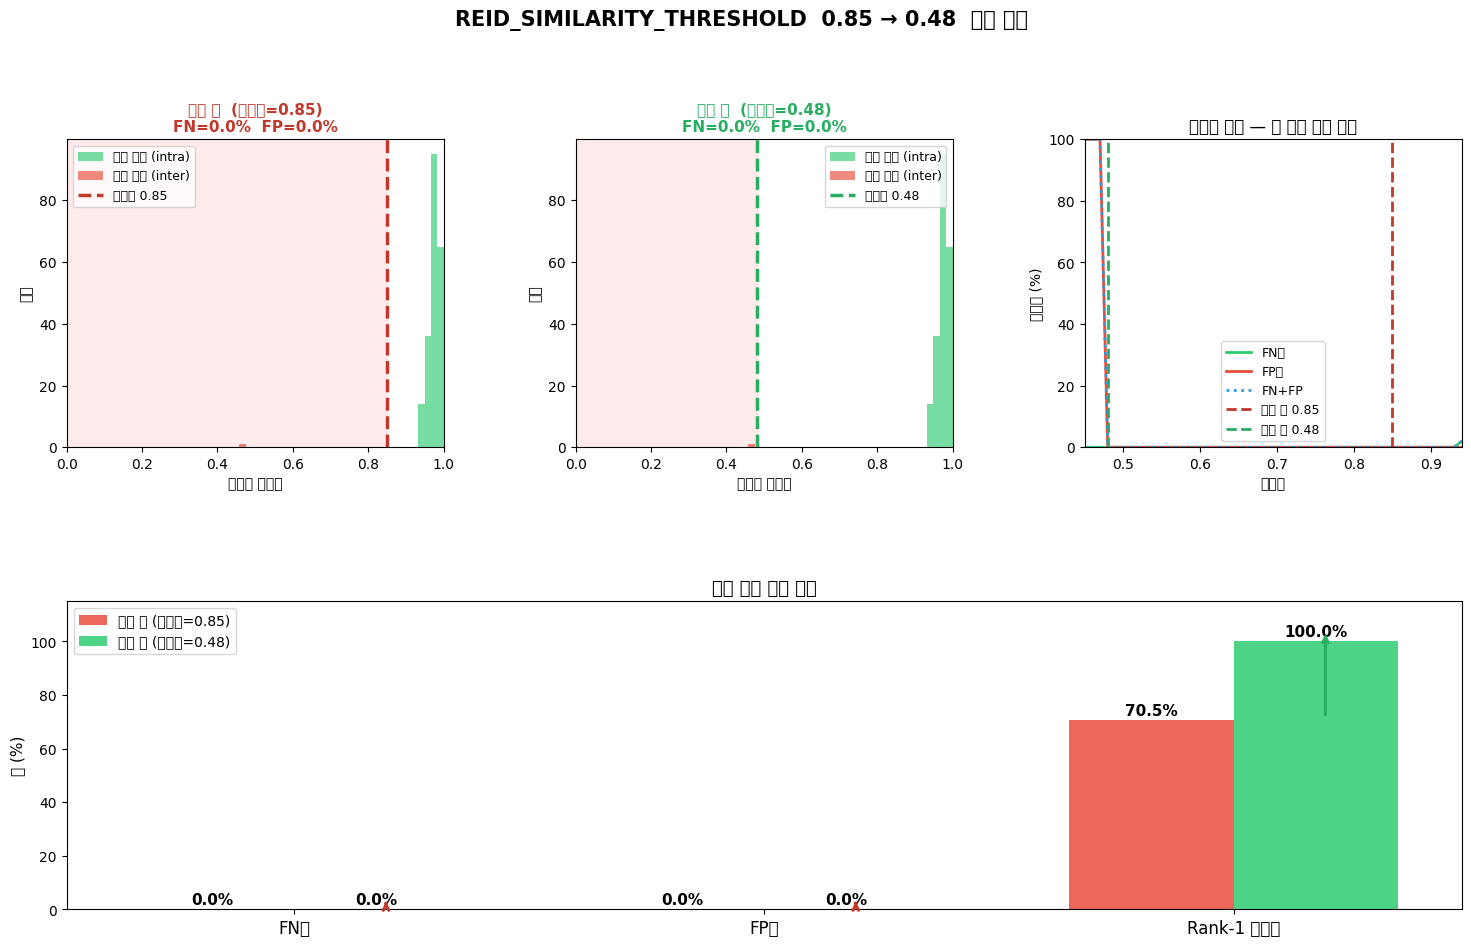


[요약]
  FN율:    0.0% → 0.0%  (+0.0%p)  ← 같은 사람 재인식 실패
  FP율:    0.0% → 0.0%  (+0.0%p)  ← 다른 사람 오인식
  Rank-1:  70.5% → 100.0%  (+29.5%p)


In [15]:
# ── 개선 전후 비교 ─────────────────────────────────────────────────────────
BEFORE_THRESH = CURRENT_THRESHOLD      # 0.85
AFTER_THRESH  = opt_threshold_x025    # 0.73 (섹션 4에서 계산)

fn_before = (intra_x025 < BEFORE_THRESH).mean()
fp_before = (inter_x025 >= BEFORE_THRESH).mean()
fn_after  = (intra_x025 < AFTER_THRESH).mean()
fp_after  = (inter_x025 >= AFTER_THRESH).mean()

r_before = simulate_matcher(data_x025, threshold=BEFORE_THRESH, strategy='single')
r_after  = simulate_matcher(data_x025, threshold=AFTER_THRESH,  strategy='single')

fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

bins = np.linspace(0, 1, 60)

# ── 상단 왼쪽/가운데: 유사도 분포 (변경 전 / 변경 후) ──────────────────────────
configs = [
    (BEFORE_THRESH, "변경 전", "#c0392b"),
    (AFTER_THRESH,  "변경 후", "#27ae60"),
]
for col, (thresh, label_prefix, title_color) in enumerate(configs):
    ax = fig.add_subplot(gs[0, col])
    ax.hist(intra_x025, bins=bins, alpha=0.65, color='#2ecc71', label='같은 사람 (intra)')
    ax.hist(inter_x025, bins=bins, alpha=0.65, color='#e74c3c', label='다른 사람 (inter)')
    ax.axvline(thresh, color=title_color, lw=2.5, ls='--', label=f'임계값 {thresh:.2f}')
    ax.axvspan(0, thresh, alpha=0.08, color='red')
    fn = (intra_x025 < thresh).mean()
    fp = (inter_x025 >= thresh).mean()
    fn_str = f"FN={fn*100:.1f}%  FP={fp*100:.1f}%"
    ax.set_title(f"{label_prefix}  (임계값={thresh:.2f})\n{fn_str}",
                 fontsize=11, color=title_color, fontweight='bold')
    ax.set_xlabel('코사인 유사도')
    ax.set_ylabel('빈도')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

# ── 상단 오른쪽: 임계값 스윕 + 두 임계값 표시 ─────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
fn_sweep = np.array([(intra_x025 < t).mean() for t in THRESHOLD_RANGE])
fp_sweep = np.array([(inter_x025 >= t).mean() for t in THRESHOLD_RANGE])
ax.plot(THRESHOLD_RANGE, fn_sweep * 100, '#2ecc71', lw=2, label='FN율')
ax.plot(THRESHOLD_RANGE, fp_sweep * 100, '#e74c3c', lw=2, label='FP율')
ax.plot(THRESHOLD_RANGE, (fn_sweep + fp_sweep) * 100, '#3498db', lw=2, ls=':', label='FN+FP')
ax.axvline(BEFORE_THRESH, color='#c0392b', lw=2, ls='--', label=f'변경 전 {BEFORE_THRESH}')
ax.axvline(AFTER_THRESH,  color='#27ae60', lw=2, ls='--', label=f'변경 후 {AFTER_THRESH:.2f}')
ax.set_xlabel('임계값')
ax.set_ylabel('오류율 (%)')
ax.set_title('임계값 스윕 — 두 설정 위치 비교')
ax.legend(fontsize=9)
ax.set_xlim(THRESHOLD_RANGE[0], THRESHOLD_RANGE[-1])
ax.set_ylim(0, 100)

# ── 하단: 핵심 지표 전후 막대 비교 ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, :])

metric_labels  = ['FN율', 'FP율', 'Rank-1 정확도']
before_vals    = [fn_before * 100, fp_before * 100, r_before['rank1_accuracy'] * 100]
after_vals     = [fn_after  * 100, fp_after  * 100, r_after['rank1_accuracy']  * 100]
is_higher_better = [False, False, True]

x = np.arange(len(metric_labels))
w = 0.35
b1 = ax.bar(x - w/2, before_vals, w,
            label=f'변경 전 (임계값={BEFORE_THRESH})', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + w/2, after_vals,  w,
            label=f'변경 후 (임계값={AFTER_THRESH:.2f})', color='#2ecc71', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 개선 방향 화살표
for i, (bv, av, higher_better) in enumerate(zip(before_vals, after_vals, is_higher_better)):
    improved = (av < bv) if not higher_better else (av > bv)
    color = '#27ae60' if improved else '#c0392b'
    mid_x  = i + w / 2 + 0.02
    ax.annotate(
        '',
        xy=(mid_x, max(av, bv) + 4),
        xytext=(mid_x, min(av, bv) + 1),
        arrowprops=dict(arrowstyle='->', color=color, lw=2.2),
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylabel('값 (%)', fontsize=11)
ax.set_title('핵심 지표 전후 비교', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 115)

plt.suptitle(f'REID_SIMILARITY_THRESHOLD  {BEFORE_THRESH} → {AFTER_THRESH:.2f}  개선 효과',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

rank1_diff = r_after["rank1_accuracy"] - r_before["rank1_accuracy"]
print(f'\n[요약]')
print(f'  FN율:    {fn_before*100:.1f}% → {fn_after*100:.1f}%  ({(fn_after-fn_before)*100:+.1f}%p)  ← 같은 사람 재인식 실패')
print(f'  FP율:    {fp_before*100:.1f}% → {fp_after*100:.1f}%  ({(fp_after-fp_before)*100:+.1f}%p)  ← 다른 사람 오인식')
print(f'  Rank-1:  {r_before["rank1_accuracy"]*100:.1f}% → {r_after["rank1_accuracy"]*100:.1f}%  ({rank1_diff*100:+.1f}%p)')


## 10. 추적기 품질 진단

BoxMOT(BotSort)가 **같은 사람을 일관된 track_id로 추적**하고 있는지 검증합니다.

**진단 항목**
1. **트랙별 썸네일 그리드** — 같은 track_id 내 시간순 썸네일로 인물 일관성 육안 확인
2. **연속 프레임 임베딩 유사도** — 인접 프레임 간 유사도 시계열 (급락 = ID switch 의심)
3. **트랙 간 동일 인물 탐색** — 서로 다른 track_id에 같은 사람이 배정된 쌍 탐색 (track fragmentation)

> **track fragmentation**: 같은 사람이 화면에서 사라졌다가 재등장할 때 BoxMOT이 새 track_id를 부여하는 현상.
> 이 쌍들이 서버 Re-ID 매칭(matcher.py)이 연결해야 하는 실제 대상입니다.


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

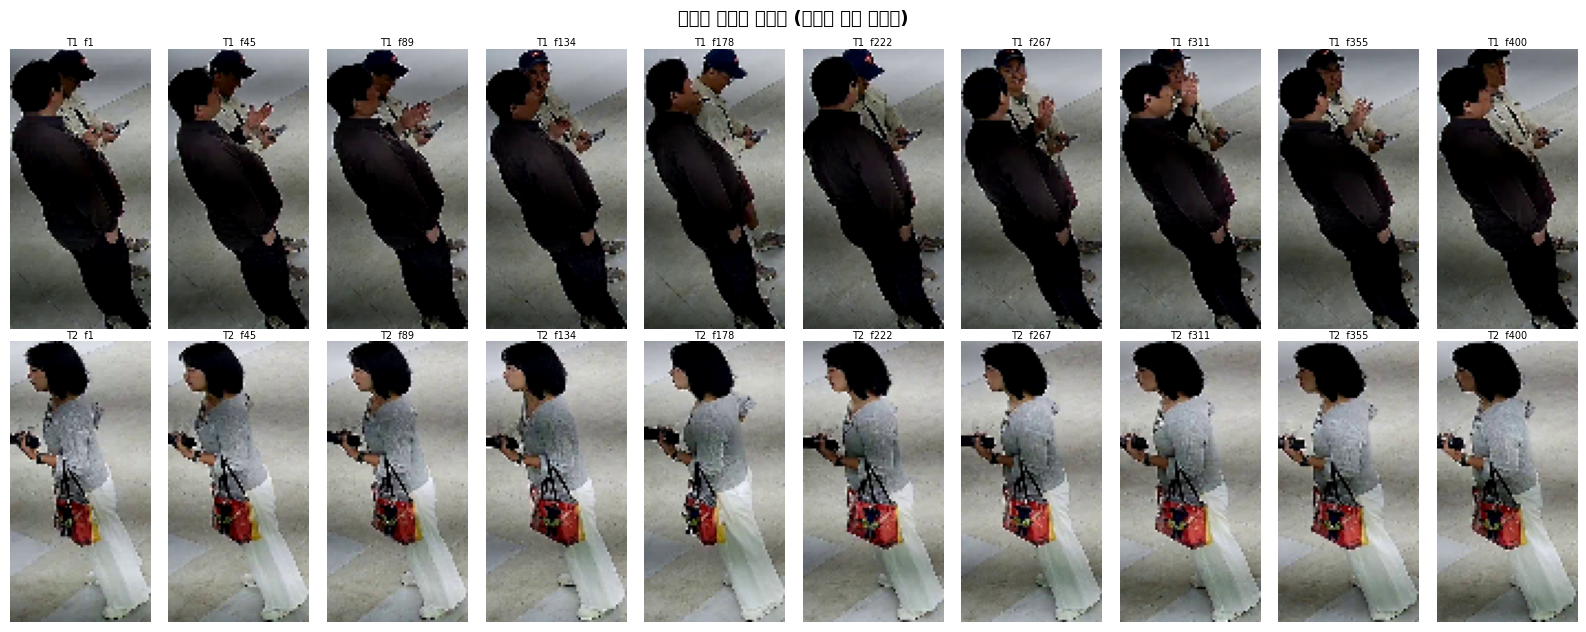

같은 행 안에 다른 인물이 섞여 있으면 ID switch가 발생한 것입니다.


In [16]:
def plot_track_thumbnails(track_data, max_cols=10, max_tracks=6):
    valid_check = {k: v for k, v in track_data.items() if len(v) >= 3}
    if not valid_check:
        print('[건너뜀] plot_track_thumbnails: 유효한 트랙 없음')
        return
    """
    각 track_id의 썸네일을 시간순으로 나열합니다.
    같은 행에 다른 인물이 보이면 ID switch가 발생한 것입니다.
    """
    valid    = {k: v for k, v in track_data.items() if len(v) >= 3}
    track_ids = sorted(valid.keys())[:max_tracks]
    n_tracks  = len(track_ids)

    fig, axes_all = plt.subplots(
        n_tracks, max_cols,
        figsize=(max_cols * 1.6, n_tracks * 3.2),
        squeeze=False,
    )
    fig.suptitle('트랙별 썸네일 그리드 (시간순 균등 샘플링)',
                 fontsize=13, fontweight='bold')

    for row_idx, tid in enumerate(track_ids):
        recs    = valid[tid]
        indices = np.linspace(0, len(recs) - 1, max_cols, dtype=int)
        sampled = [recs[i] for i in indices]

        for col_idx in range(max_cols):
            ax = axes_all[row_idx][col_idx]
            ax.axis('off')
            if col_idx < len(sampled):
                rec   = sampled[col_idx]
                thumb = rec.get('thumbnail')
                if thumb is not None and thumb.size > 0:
                    ax.imshow(cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB))
                ax.set_title(f'T{tid}  f{rec["frame"]}', fontsize=7, pad=2)

        # 행 레이블 (왼쪽)
        axes_all[row_idx][0].set_ylabel(
            f'Track {tid}\n({len(recs)}프레임)',
            fontsize=9, rotation=0, labelpad=55, va='center',
        )

    plt.tight_layout()
    plt.show()
    print('같은 행 안에 다른 인물이 섞여 있으면 ID switch가 발생한 것입니다.')


plot_track_thumbnails(data_x025)


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

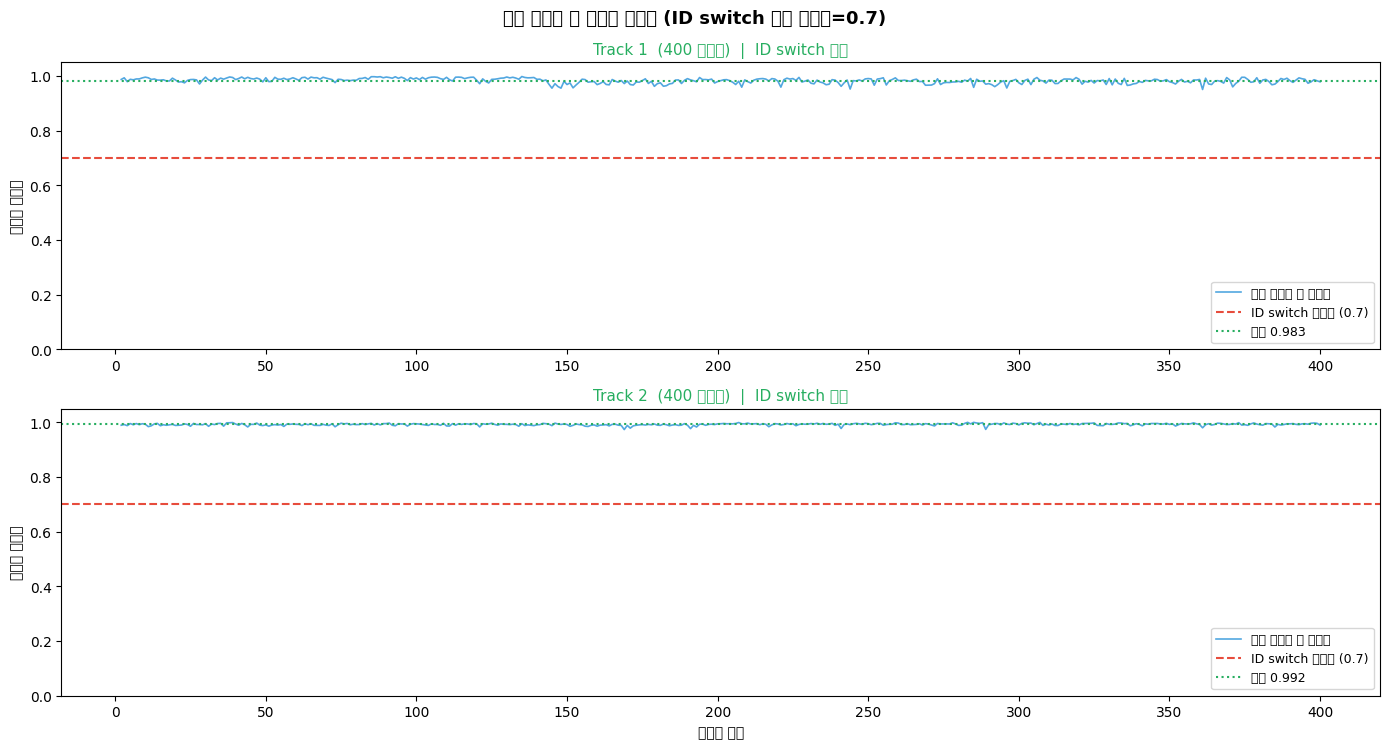


[추적기 품질 요약]
  Track     프레임      인접평균      인접최소     std    switch 의심   switch율
  -----------------------------------------------------------------
      1     400     0.983     0.951   0.009            0     0.0%
      2     400     0.992     0.973   0.004            0     0.0%

  전체 ID switch 의심 건수: 0건
  판정: 추적기 품질 양호 — 심각한 ID switch 없음
  => 섹션 4 intra-track 유사도 분포 신뢰 가능


In [17]:
ID_SWITCH_THRESH = 0.70  # 인접 프레임 간 유사도가 이 값 미만이면 ID switch 의심


def analyze_track_continuity(track_data, switch_thresh=ID_SWITCH_THRESH):
    """
    같은 track_id 내 인접 프레임 간 임베딩 유사도를 시계열로 그립니다.
    유사도가 갑자기 떨어지는 구간은 ID switch 의심 지점입니다.
    """
    valid     = {k: v for k, v in track_data.items() if len(v) >= 3}
    track_ids = sorted(valid.keys())
    n         = len(track_ids)

    if n == 0:
        print('[건너뜀] analyze_track_continuity: 유효한 트랙 없음')
        return []

    fig, axes = plt.subplots(n, 1, figsize=(14, 3.8 * n), squeeze=False)
    fig.suptitle(
        f'인접 프레임 간 임베딩 유사도 (ID switch 감지 임계값={switch_thresh})',
        fontsize=13, fontweight='bold',
    )

    summary = []

    for ax, tid in zip(axes[:, 0], track_ids):
        recs   = valid[tid]
        frames = [r['frame'] for r in recs]
        vecs   = np.stack([r['vector'] for r in recs])

        # 인접 프레임 쌍 간 코사인 유사도
        sims       = np.array([float(np.dot(vecs[i], vecs[i + 1])) for i in range(len(vecs) - 1)])
        sim_frames = frames[1:]
        switch_mask = sims < switch_thresh
        n_switches  = int(switch_mask.sum())

        # ── 기본 시계열 ──────────────────────────────────────────────────────
        ax.plot(sim_frames, sims, color='#3498db', lw=1.2, alpha=0.85,
                label='인접 프레임 간 유사도')
        ax.axhline(switch_thresh, color='#e74c3c', lw=1.5, ls='--',
                   label=f'ID switch 임계값 ({switch_thresh})')
        ax.axhline(sims.mean(), color='#27ae60', lw=1.5, ls=':',
                   label=f'평균 {sims.mean():.3f}')

        # ── ID switch 의심 구간 강조 ─────────────────────────────────────────
        for fr, sim, is_sw in zip(sim_frames, sims, switch_mask):
            if is_sw:
                ax.axvspan(fr - 2, fr + 2, alpha=0.25, color='red')
                ax.plot(fr, sim, 'rv', markersize=9, zorder=5)

        status = f'ID switch 의심 {n_switches}건' if n_switches > 0 else 'ID switch 없음'
        ax.set_title(
            f'Track {tid}  ({len(recs)} 프레임)  |  {status}',
            fontsize=11,
            color='#c0392b' if n_switches > 0 else '#27ae60',
        )
        ax.set_ylabel('코사인 유사도')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9, loc='lower right')

        summary.append({
            'track_id':    tid,
            'n_frames':    len(recs),
            'mean_sim':    float(sims.mean()),
            'min_sim':     float(sims.min()),
            'std_sim':     float(sims.std()),
            'n_switches':  n_switches,
            'switch_rate': float(n_switches / max(1, len(sims))),
        })

    axes[-1, 0].set_xlabel('프레임 번호')
    plt.tight_layout()
    plt.show()

    # ── 요약 테이블 ──────────────────────────────────────────────────────────
    print('\n[추적기 품질 요약]')
    hdr = f"{'Track':>7}  {'프레임':>6}  {'인접평균':>8}  {'인접최소':>8}  {'std':>6}  {'switch 의심':>11}  {'switch율':>8}"
    print(hdr)
    print('  ' + '-' * 65)
    total_sw = 0
    for r in summary:
        flag = ' (!)' if r['n_switches'] > 0 else ''
        print(
            f"{r['track_id']:>7}  "
            f"{r['n_frames']:>6}  "
            f"{r['mean_sim']:>8.3f}  "
            f"{r['min_sim']:>8.3f}  "
            f"{r['std_sim']:>6.3f}  "
            f"{r['n_switches']:>11}{flag}  "
            f"{r['switch_rate']:>7.1%}"
        )
        total_sw += r['n_switches']

    print(f'\n  전체 ID switch 의심 건수: {total_sw}건')

    contaminated = [r for r in summary if r['n_switches'] > 0]
    if not contaminated:
        print('  판정: 추적기 품질 양호 — 심각한 ID switch 없음')
        print('  => 섹션 4 intra-track 유사도 분포 신뢰 가능')
    else:
        sw_tracks = [str(r['track_id']) for r in contaminated]
        print(f'  판정: Track {", ".join(sw_tracks)}에서 ID switch 의심')
        print('  => 해당 트랙의 intra-track 유사도가 오염되었을 수 있음')
        print('  => 위 썸네일 그리드의 빨간 삼각형 구간을 직접 확인하세요')

    return summary


track_quality = analyze_track_continuity(data_x025)


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

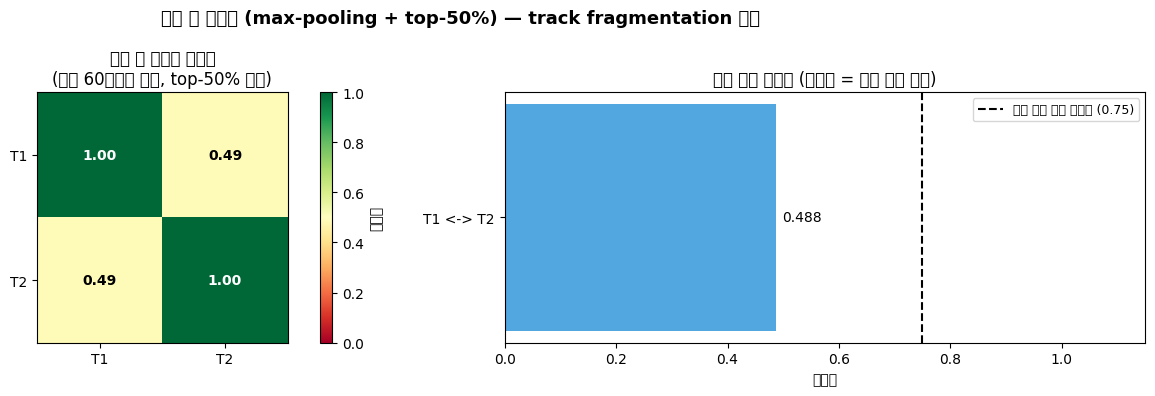


같은 사람 의심 쌍 없음 (임계값=0.75)
모든 트랙이 서로 다른 인물로 판단됩니다.

[track fragmentation 진단 요약]
  분석 트랙 수: 2개
  같은 사람 의심 쌍: 0쌍 / 전체 1쌍


In [18]:
FRAG_THRESH  = 0.75   # 이 값 이상이면 같은 사람 의심
FRAG_SAMPLES = 60     # 트랙당 균등 샘플링 수 (30 → 60: 긴 트랙에서 좋은 프레임 포착 확률 향상)
FRAG_TOP_PCT = 0.5    # 상위 몇 % 의 best-match 값만 평균에 사용 (나쁜 품질 프레임 제거)


def track_pair_sim(vecs_a, vecs_b, top_pct=FRAG_TOP_PCT):
    """
    max-pooling + top-k% 필터링 유사도.

    1. sim_mat[i, j] = A의 i번째 임베딩과 B의 j번째 임베딩 간 코사인 유사도
    2. 각 행/열의 최댓값 = 그 임베딩이 상대 트랙에서 찾은 최고 유사도
    3. 상위 top_pct 값만 평균 = 포즈·조명이 나쁜 프레임의 저유사도를 배제
    """
    sim_mat = vecs_a @ vecs_b.T               # (|A|, |B|)
    best_a  = np.sort(sim_mat.max(axis=1))    # A 시점에서 B로의 최고 유사도 (오름차순)
    best_b  = np.sort(sim_mat.max(axis=0))    # B 시점에서 A로의 최고 유사도
    k_a = max(1, int(len(best_a) * top_pct))  # 상위 50% 인덱스
    k_b = max(1, int(len(best_b) * top_pct))
    return float((best_a[-k_a:].mean() + best_b[-k_b:].mean()) / 2)


def sample_vecs(recs, n=FRAG_SAMPLES):
    """트랙 전체에서 균등하게 n개 임베딩을 샘플링합니다."""
    idxs = np.linspace(0, len(recs) - 1, min(n, len(recs)), dtype=int)
    return np.stack([recs[i]['vector'] for i in idxs])


def find_fragmented_tracks(track_data, frag_thresh=FRAG_THRESH):
    """
    트랙 간 max-pooling + top-50% 유사도를 계산하고,
    같은 사람이 다른 track_id를 받은 쌍(track fragmentation)을 찾습니다.
    """
    valid     = {k: v for k, v in track_data.items() if len(v) >= 3}
    track_ids = sorted(valid.keys())
    n         = len(track_ids)

    if n < 2:
        print('[건너뜀] find_fragmented_tracks: 비교할 트랙이 2개 미만')
        return []

    sampled_vecs = {tid: sample_vecs(recs) for tid, recs in valid.items()}

    # N×N 유사도 행렬
    sim_mat = np.eye(n)
    for i, t1 in enumerate(track_ids):
        for j, t2 in enumerate(track_ids):
            if j > i:
                s = track_pair_sim(sampled_vecs[t1], sampled_vecs[t2])
                sim_mat[i, j] = s
                sim_mat[j, i] = s

    pairs = []
    for i, t1 in enumerate(track_ids):
        for j, t2 in enumerate(track_ids):
            if j > i:
                pairs.append((t1, t2, sim_mat[i, j]))
    pairs.sort(key=lambda x: -x[2])

    # ── 히트맵 + 막대 차트 ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n * 1.2)))
    fig.suptitle(
        f'트랙 간 유사도 (max-pooling + top-{int(FRAG_TOP_PCT*100)}%) — track fragmentation 탐색',
        fontsize=13, fontweight='bold',
    )

    ax = axes[0]
    im = ax.imshow(sim_mat, vmin=0, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'T{t}' for t in track_ids])
    ax.set_yticklabels([f'T{t}' for t in track_ids])
    plt.colorbar(im, ax=ax, label='유사도')
    for i in range(n):
        for j in range(n):
            txt_color = 'white' if sim_mat[i, j] > 0.7 else 'black'
            ax.text(j, i, f'{sim_mat[i, j]:.2f}',
                    ha='center', va='center', fontsize=10,
                    color=txt_color, fontweight='bold')
    ax.set_title(f'트랙 간 코사인 유사도\n(균등 {FRAG_SAMPLES}프레임 샘플, top-{int(FRAG_TOP_PCT*100)}% 평균)')

    ax = axes[1]
    labels     = [f'T{t1} <-> T{t2}' for t1, t2, _ in pairs]
    sims_vals  = [s for _, _, s in pairs]
    bar_colors = ['#e74c3c' if s >= frag_thresh else '#3498db' for s in sims_vals]
    bars = ax.barh(labels, sims_vals, color=bar_colors, alpha=0.85)
    ax.axvline(frag_thresh, color='black', lw=1.5, ls='--',
               label=f'같은 사람 의심 임계값 ({frag_thresh})')
    for bar, s in zip(bars, sims_vals):
        ax.text(min(s + 0.01, 1.08), bar.get_y() + bar.get_height() / 2,
                f'{s:.3f}', va='center', fontsize=10)
    ax.set_xlabel('유사도')
    ax.set_xlim(0, 1.15)
    ax.set_title('트랙 쌍별 유사도 (빨간색 = 같은 사람 의심)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── 같은 사람 의심 쌍: 썸네일 비교 ────────────────────────────────────
    frag_pairs = [(t1, t2, s) for t1, t2, s in pairs if s >= frag_thresh]

    if frag_pairs:
        print(f'\n[track fragmentation 의심 쌍] (유사도 >= {frag_thresh})')
        for t1, t2, s in frag_pairs:
            print(f'  Track {t1} <-> Track {t2}  유사도={s:.3f}  => 동일 인물, Re-ID 매칭 필요')

        n_fp  = len(frag_pairs)
        n_col = 6
        fig, axes_g = plt.subplots(n_fp, n_col,
                                   figsize=(n_col * 2.2, n_fp * 3.5),
                                   squeeze=False)
        fig.suptitle('같은 사람 의심 트랙 쌍 — 썸네일 비교 (왼쪽 3열 vs 오른쪽 3열)',
                     fontsize=12, fontweight='bold')

        border_colors = ['#e74c3c', '#3498db']
        for row, (t1, t2, s) in enumerate(frag_pairs):
            for side, (tid, recs) in enumerate([(t1, valid[t1]), (t2, valid[t2])]):
                idxs = np.linspace(0, len(recs) - 1, 3, dtype=int)
                bc   = border_colors[side]
                for k, idx in enumerate(idxs):
                    ax  = axes_g[row][side * 3 + k]
                    rec = recs[idx]
                    thumb = rec.get('thumbnail')
                    if thumb is not None and thumb.size > 0:
                        ax.imshow(cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB))
                    ax.set_title(f'T{tid}  f{rec["frame"]}', fontsize=8)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_edgecolor(bc)
                        spine.set_linewidth(3)
                        spine.set_visible(True)
            axes_g[row][2].set_xlabel(f'유사도={s:.3f}', fontsize=10, fontweight='bold')

        plt.tight_layout()
        plt.show()
    else:
        print(f'\n같은 사람 의심 쌍 없음 (임계값={frag_thresh})')
        print('모든 트랙이 서로 다른 인물로 판단됩니다.')

    print('\n[track fragmentation 진단 요약]')
    print(f'  분석 트랙 수: {n}개')
    print(f'  같은 사람 의심 쌍: {len(frag_pairs)}쌍 / 전체 {len(pairs)}쌍')
    if frag_pairs:
        print(f'  추정 실제 인물 수: {n - len(frag_pairs)}명')
        print('  => Re-ID 매칭이 없으면 같은 사람이 재등장마다 새 Global ID를 받게 됩니다')
        print(f'  => REID_SIMILARITY_THRESHOLD 를 0.73으로 낮추면 이 쌍들의 매칭 성공률이 높아집니다')

    return frag_pairs


frag_pairs = find_fragmented_tracks(data_x025)


In [19]:
# ── 결과 저장 (papermill 배치 실행 시 자동 호출) ──────────────────────────────
import pickle, pathlib

out_dir  = pathlib.Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
vid_name = pathlib.Path(VIDEO_PATH).stem

try:
    _opt = float(opt_threshold_x025)
except NameError:
    _opt = None
try:
    _intra = intra_x025
    _inter = inter_x025
except NameError:
    _intra = _inter = __import__('numpy').array([])

save_data = {
    'video_path':    VIDEO_PATH,
    'data_x025':     data_x025,
    'intra_x025':    _intra,
    'inter_x025':    _inter,
    'opt_threshold': _opt,
}

# 선택적 결과 (섹션 5·10이 실행된 경우)
for key, getter in [
    ('data_x1',       lambda: data_x1),
    ('intra_x1',      lambda: intra_x1),
    ('inter_x1',      lambda: inter_x1),
    ('track_quality', lambda: track_quality),
    ('frag_pairs',    lambda: frag_pairs),
]:
    try:
        save_data[key] = getter()
    except NameError:
        pass

out_path = out_dir / f'{vid_name}.pkl'
with open(out_path, 'wb') as _f:
    pickle.dump(save_data, _f)

print(f'저장 완료: {out_path}')
print(f'  트랙 수     : {len(data_x025)}')
print(f'  intra 쌍    : {len(intra_x025)}')
print(f'  inter 쌍    : {len(inter_x025)}')
print(f'  최적 임계값 : {opt_threshold_x025:.2f}')


저장 완료: results\16300000.pkl
  트랙 수     : 2
  intra 쌍    : 210
  inter 쌍    : 1
  최적 임계값 : 0.48
